In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Подготовка данных

In [3]:
import pandas as pd
import numpy as np
import math
import time
import os
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:.2f}'.format)

In [4]:
shot_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/диплом 2026/db_dvt_data.csv', header=0, index_col=0)
frames_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/диплом 2026/db_frames.csv', header=0)
metadata_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/диплом 2026/db_metadata.csv', header=0, index_col=0)

In [ ]:
metadata_df['released'] = pd.to_datetime(metadata_df['released'])
metadata_df['month'] = metadata_df['released'].dt.month
metadata_df['screen_ratio'] = metadata_df['height'] / metadata_df['width']

shot_df['timecode'] = pd.to_datetime(shot_df['timecode'], format='%H:%M:%S').dt.time
# shot_df['time_minute'] = shot_df['timecode']
frames_df = pd.merge(frames_df, shot_df, on=['title', 'shot_index'], how='left')
frames_df = frames_df[frames_df['shot_index'] >= 0]

In [ ]:
# заменяем значения на пропуски там, где много лиц, т.к. стоит площадь 0
frames_df.loc[frames_df['faces'] > 1, 'fsquare'] = np.nan

In [ ]:
frames_df['faces_bool'] = frames_df['faces'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
def closeup_degree(x):
    if x > 0.25:
        return "closeup"
    elif x > 0.10:
        return "medium closeup"
    elif x > 0 or math.isnan(x):
        return 'human'
    else:
        return 'none'

frames_df['closeup'] = frames_df['fsquare'].apply(closeup_degree)

In [ ]:
#новый столбец для таймкода
frames_df['frame_time'] = frames_df['nframe'].apply(lambda x: time.strftime('%H:%M:%S', time.gmtime(x/24)))

In [ ]:
duplicates = frames_df.duplicated(subset=['title', 'nframe'])

In [ ]:
frames_df[duplicates == True]['title'].nunique()

0

In [ ]:
frames_df.isna().mean() * 100 # нет пропусков, кроме крупного плана

,0
nframe,0.00
faces,0.00
fsquare,5.88
neyes,0.00
nobjects,0.00
brightness,0.00
shot_index,0.00
title,0.00
start,0.00
end,0.00


In [ ]:
metadata_df['mean_scene'] = metadata_df['title'].apply(lambda x: shot_df[shot_df['title'] == x]['length'].mean()/24)
metadata_df['median_scene'] = metadata_df['title'].apply(lambda x: shot_df[shot_df['title'] == x]['length'].median()/24)

In [ ]:
for feature in ['faces_bool', 'fsquare', 'nobjects', 'brightness']:
    metadata_df[feature] = metadata_df['title'].apply(lambda x: frames_df[frames_df['title'] == x][feature].mean())

In [ ]:
def add_closeup_data(title):
    df = frames_df[frames_df['title'] == title]
    data = df['closeup'].value_counts()
    data_sum = df['closeup'].count()
    none = data['none']
    human = data['human']
    medium = data['medium closeup']
    if 'closeup' in data:
        close = data['closeup']
    else:
        close = 0
    return pd.Series({
        'cu_none': none/data_sum,
        'cu_human': human/data_sum,
        'cu_medium': medium/data_sum,
        'cu_close': close/data_sum,
    })

# Применяем к колонке
metadata_df[['cu_none', 'cu_human', 'cu_medium', 'cu_close']] = metadata_df['title'].apply(add_closeup_data)
metadata_df['cu'] = metadata_df['cu_medium'] + metadata_df['cu_close']

In [ ]:
metadata_df.sample(2)

,title,year,genre,eng_title,rus_title,height,width,frame_count,shot_count,film_start,...,median_scene,faces_bool,fsquare,nobjects,brightness,cu_none,cu_human,cu_medium,cu_close,cu
index,,,,,,,,,,,,,,,,,,,,,
107,The_Remains_of_the_Day,1993,romance,The Remains of the Day,На исходе дня,304,720,185065,770,2747,...,6.31,0.45,0.02,116.81,37.04,0.55,0.41,0.04,0.00,0.04
84,Bad_Lieutenant,1992,thriller,Bad Lieutenant,Плохой лейтенант,400,720,128609,325,720,...,8.25,0.26,0.02,80.74,31.13,0.74,0.21,0.03,0.03,0.05


In [ ]:
shot_df.sample(2)

,title,shot_index,start,end,length,time_length,timecode,part,part_of_6,part_of_9
id,,,,,,,,,,
10448,Above_Suspicion,878,105386,105448,62,2.58,01:13:11,3,5,8
5697,A_Perfect_World,948,102181,102205,24,1.00,01:10:57,2,4,5


In [ ]:
frames_df.sample(2)

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,length,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time
816764,63576,0,0.00,1,75,64.10,292,Gettysburg,63359.00,63752.00,393.00,16.38,00:43:59,1.00,1.00,2.00,0,none,00:44:09
985285,5544,0,0.00,0,147,42.13,15,Little_Women,5384.00,5595.00,211.00,8.79,00:03:44,1.00,1.00,1.00,0,none,00:03:51


## Одиночные характеристики

In [ ]:
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 298 entries, 0 to 297
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         298 non-null    object        
 1   year          298 non-null    int64         
 2   genre         298 non-null    object        
 3   eng_title     298 non-null    object        
 4   rus_title     298 non-null    object        
 5   height        298 non-null    int64         
 6   width         298 non-null    int64         
 7   frame_count   298 non-null    int64         
 8   shot_count    298 non-null    int64         
 9   film_start    298 non-null    int64         
 10  film_end      298 non-null    int64         
 11  imdb          298 non-null    object        
 12  mark          298 non-null    float64       
 13  rated         297 non-null    object        
 14  released      298 non-null    datetime64[ns]
 15  runtime       298 non-null    int64         


### Длительность фильма

<Axes: >

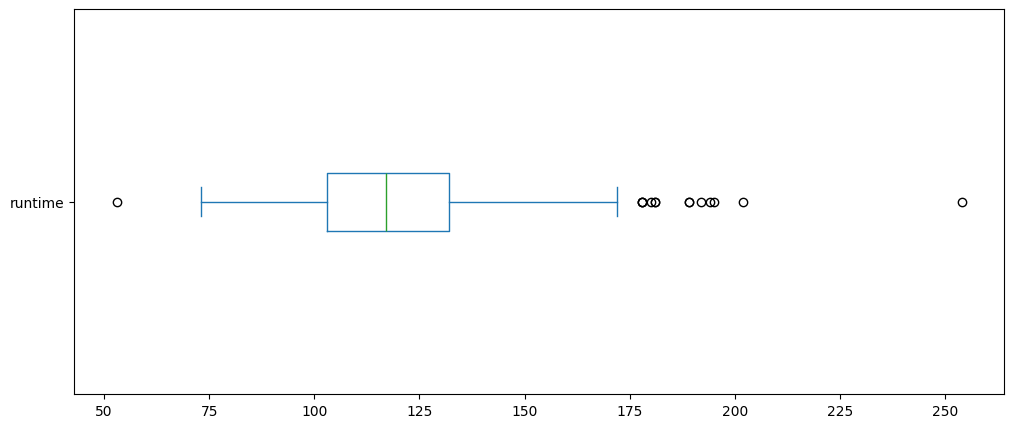

In [ ]:
metadata_df['runtime'].plot(kind='box', vert=False, figsize=(12, 5))

In [ ]:
metadata_df['runtime'].describe()

,runtime
count,298.00
mean,119.86
std,24.62
min,53.00
25%,103.00
50%,117.00
75%,132.00
max,254.00


In [ ]:
print(metadata_df['runtime'].quantile(0.05))
print(metadata_df['runtime'].quantile(0.95))

88.85
170.0


In [ ]:
Q1 = metadata_df['runtime'].quantile(0.25)
Q3 = metadata_df['runtime'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [ ]:
metadata_df[metadata_df['runtime'] >= upper].sort_values('runtime')[['title', 'year', 'genre', 'runtime']]

,title,year,genre,runtime
index,,,,
158,Casino,1995,drama,178
160,Braveheart,1995,history,178
256,Meet_Joe_Black,1998,romance,178
95,Bound_by_Honor,1993,crime,180
280,Sunshine,1999,history,181
11,Dances_with_Wolves,1990,drama,181
41,JFK,1991,history,189
279,The_Green_Mile,1999,drama,189
162,Nixon,1995,history,192


In [ ]:
metadata_df[['title', 'year', 'genre', 'runtime']].sort_values('runtime')

,title,year,genre,runtime
index,,,,
78,Surviving_Desire,1992,romance,53
182,Mystery_Science_Theater_3000_The_Movie,1996,comedy,73
282,Wisconsin_Death_Trip,1999,history,76
31,Showdown_in_Little_Tokyo,1991,action,79
111,Freaked,1993,sci-fi,80
...,...,...,...,...
162,Nixon,1995,history,192
226,Titanic,1997,romance,194
98,Schindler's_List,1993,drama,195


### Дата выхода

In [ ]:
metadata_df.value_counts('month')

,count
month,
12,36
10,33
1,28
11,28
2,26
7,25
8,24
9,24
5,23


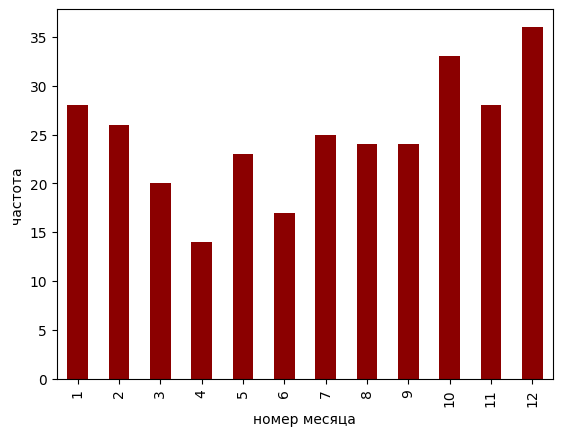

In [ ]:
metadata_df.value_counts('month').sort_index().plot(kind='bar', color='darkred')
plt.xlabel('номер месяца')
plt.ylabel('частота')
plt.show()

### Жанры

In [ ]:
metadata_df['genre'].value_counts()

,count
genre,
action,30
comedy,30
crime,30
drama,30
horror,30
romance,30
thriller,30
sci-fi,30
history,29


In [ ]:
metadata_df['genres'].value_counts()

,count
genres,
"Action, Crime, Drama",17
"Crime, Drama, Thriller",14
"Drama, Romance",13
"Comedy, Drama, Romance",10
"Action, Adventure, Sci-Fi",8
...,...
"Comedy, Horror, Thriller",1
"Crime, Romance, Thriller",1
"Crime, Drama, Fantasy",1


In [ ]:
genres_all = list(set(metadata_df['genres'].str.cat(sep=", ").split(', ')))
genres = []

for g in genres_all:
    share = round(metadata_df[metadata_df['genres'].str.contains(g)].shape[0]/298*100, 2)
    if share > 5:
        print(g, share) # доля (в процентах) фильмов с таким жанром
        genres.append(g)

Fantasy 6.71
Crime 27.18
Romance 18.79
Biography 8.39
War 6.04
Mystery 10.74
Drama 68.12
Comedy 22.48
History 9.73
Sci-Fi 11.41
Action 27.85
Horror 11.74
Thriller 21.48
Adventure 12.75


/tmp/ipykernel_5231/579021962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genres_df[g] = genres_df['genres'].apply(lambda x: 1 if g in x else 0)
/tmp/ipykernel_5231/579021962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genres_df[g] = genres_df['genres'].apply(lambda x: 1 if g in x else 0)
/tmp/ipykernel_5231/579021962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

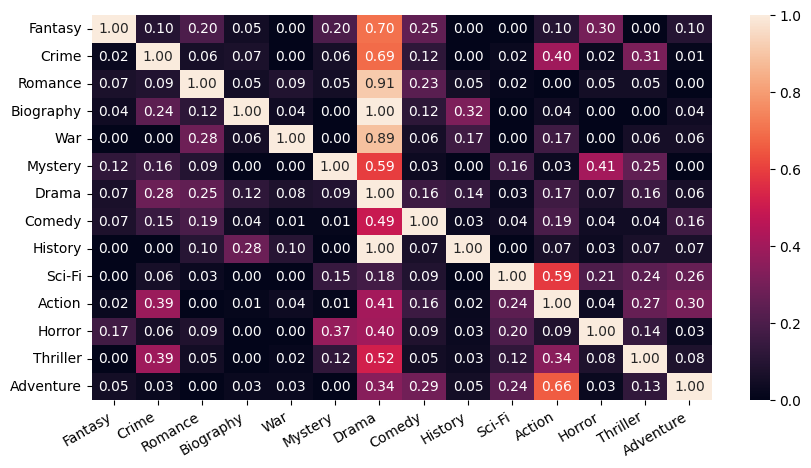

In [ ]:
# тепловая карта совстречаемости жанров
genres_df = metadata_df[['genres']]
for g in genres:
    genres_df[g] = genres_df['genres'].apply(lambda x: 1 if g in x else 0)

genre_matrix = genres_df[genres].values

# Строим матрицу совстречаемости через матричное умножение
co_occurrence = np.dot(genre_matrix.T, genre_matrix)

# Преобразуем в DataFrame с названиями жанров
co_occurrence_df = pd.DataFrame(
    co_occurrence,
    index=genres,
    columns=genres
)

# Строим тепловую карту
df_norm = co_occurrence_df.div(co_occurrence_df.max(axis=1), axis=0)
from matplotlib.colors import LogNorm
plt.figure(figsize=(10, 5))
ax = sns.heatmap(df_norm, annot=True, cmap='rocket', fmt='.2f', vmin=0, vmax=1)
#plt.title('Совстречаемость жанров')
ax.tick_params(axis='x', rotation=30)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

### Соотношение сторон экрана

<Axes: >

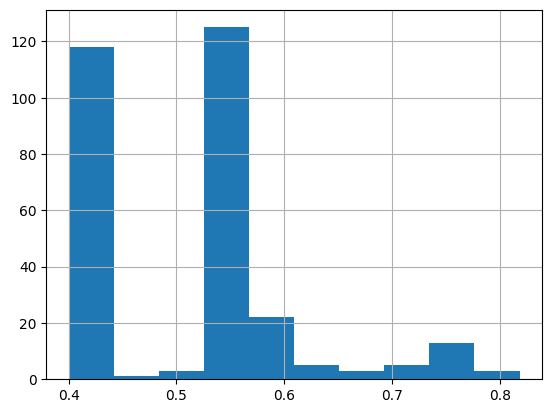

In [ ]:
metadata_df['screen_ratio'].hist(bins=10)

In [ ]:
metadata_df['screen_ratio'].describe()

,screen_ratio
count,298.00
mean,0.52
std,0.09
min,0.40
25%,0.42
50%,0.54
75%,0.56
max,0.82


In [ ]:
round(metadata_df['screen_ratio'], 2).value_counts().head(6)

,count
screen_ratio,
0.42,100
0.56,53
0.55,31
0.53,20
0.54,20
0.57,18


In [ ]:
metadata_df.sort_values('screen_ratio').tail(15)[['eng_title', 'rus_title', 'year', 'screen_ratio']]

,eng_title,rus_title,year,screen_ratio
index,,,,
108,A Bronx Tale,Бронкская история,1993,0.74
174,Above Suspicion,Вне подозрений,1995,0.75
284,Stir of Echoes,Отзвуки эха,1999,0.75
181,Swingers,Тусовщики,1996,0.75
228,"Niagara, Niagara","Ниагара, Ниагара",1997,0.75
64,Reservoir Dogs,Бешеные псы,1992,0.75
57,McBain,МакБэйн,1991,0.75
229,Men in Black,Люди в чёрном,1997,0.75
257,Dangerous Beauty,Честная куртизанка,1998,0.75


### Съёмочная группа

In [10]:
directors_all = list(set(metadata_df['directors'].str.cat(sep=", ").split(', ')))
directors = []

for d in directors_all:
    num = metadata_df[metadata_df['directors'].str.contains(d)].shape[0]
    if num > 2:
        print(d, num)
        directors.append(d)

David Fincher 3
Terry Gilliam 3
Quentin Tarantino 3
Clint Eastwood 3
Paul Verhoeven 3
Ang Lee 3
Ethan Coen 4
Rob Reiner 3
Woody Allen 3
Tim Burton 5
James Cameron 3
Robert Rodriguez 4
Abel Ferrara 4
Steven Spielberg 4
Neil Jordan 4
Wes Craven 4
Martin Scorsese 3
Tony Scott 4
Oliver Stone 4
Joel Schumacher 3
Joel Coen 4
Roland Emmerich 4
Sam Raimi 3


In [ ]:
len(directors)

23

In [11]:
writers_all = list(set(metadata_df['writers'].str.cat(sep=", ").split(', ')))
writers = []

for w in writers_all:
    num = metadata_df[metadata_df['writers'].str.contains(w)].shape[0]
    if num > 2:
        print(w, num)
        writers.append(w)

Shane Black 3
Ethan Coen 4
James Cameron 3
David Mamet 3
Dean Devlin 4
Andrew Kevin Walker 3
Quentin Tarantino 6
Woody Allen 3
Tom Clancy 3
Kevin Williamson 3
David Twohy 4
Bruce Joel Rubin 3
Roland Emmerich 3
David Koepp 4
Neil Jordan 3
Richard LaGravenese 3
Steven Zaillian 3
Donald E. Stewart 3
Roger Avary 3
Stephen King 4
Joel Coen 4


In [ ]:
len(writers)

21

In [12]:
actors_all = list(set(metadata_df['actors'].str.cat(sep=", ").split(', ')))
actors = []

for a in actors_all:
    num = metadata_df[metadata_df['actors'].str.contains(a)].shape[0]
    if num > 3:
        print(a, num)
        actors.append(a)

Bruce Willis 5
Jeff Bridges 4
Sharon Stone 4
Gene Hackman 4
Sandra Bullock 4
Keanu Reeves 5
Robert Duvall 4
Kevin Bacon 5
Liam Neeson 6
Tim Robbins 4
Kevin Costner 4
Tom Hanks 4
Johnny Depp 5
Brad Pitt 7
Sam Neill 5
Joe Pesci 5
Christopher Walken 4
Winona Ryder 5
Jack Nicholson 4
Leon 4
John Cusack 4
Nicolas Cage 5
Willem Dafoe 5
Samuel L. Jackson 7
Ralph Fiennes 6
Al Pacino 7
Danny Glover 4
Sean Penn 4
Robert De Niro 7
Clint Eastwood 4
Michael Douglas 4
John Turturro 4
Kevin Spacey 4
Harvey Keitel 4
Matt Damon 4
Anthony Hopkins 10
Gary Oldman 5
Tom Cruise 5


In [ ]:
len(actors)

38

### Другие метаданные

In [ ]:
metadata_df['rated'].value_counts()

rated
R            207
PG-13         55
PG            27
Not Rated      4
TV-PG          1
Unrated        1
G              1
NC-17          1
Name: count, dtype: int64

<Axes: >

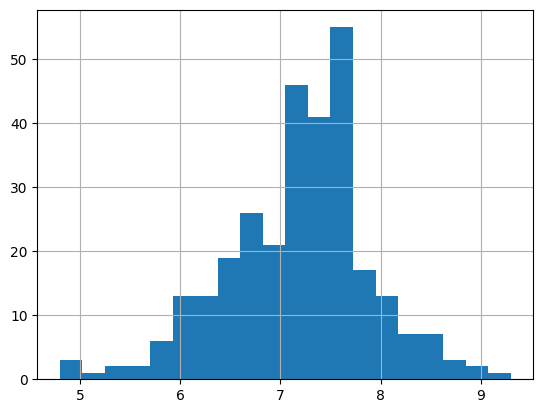

In [ ]:
metadata_df['mark'].hist(bins=20)

### Длина плана

<Axes: >

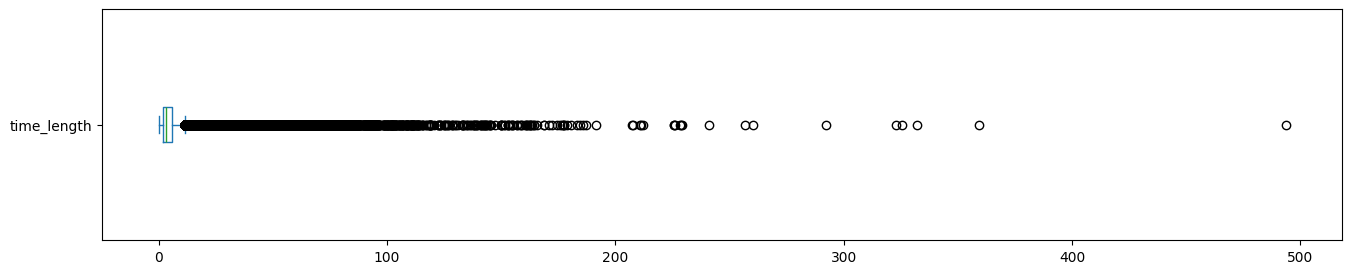

In [ ]:
shot_df['time_length'].plot(kind='box', vert=False, figsize=(16, 3))

<Axes: >

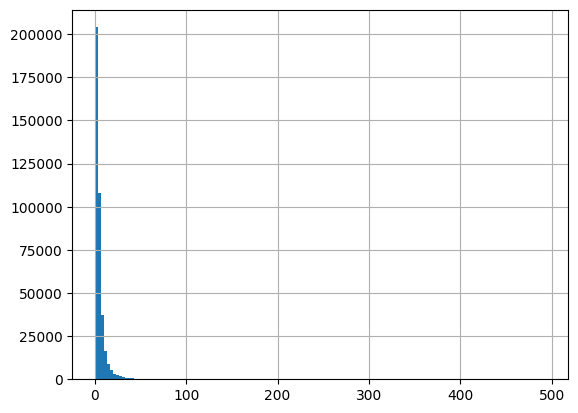

In [ ]:
shot_df['time_length'].hist(bins=150)

In [ ]:
shot_df['time_length'].describe()

,time_length
count,392088.00
mean,5.20
std,7.38
min,0.04
25%,1.92
50%,3.17
75%,5.75
max,493.67


In [ ]:
shot_df['time_length'].quantile(0.9)

np.float64(10.458333333333334)

In [ ]:
shot_df['time_length'].quantile(0.95)

np.float64(15.583333333333334)

In [ ]:
Q1 = shot_df['time_length'].quantile(0.25)
Q3 = shot_df['time_length'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
shot_df[shot_df['time_length'] >= upper].sort_values('time_length')

In [ ]:
shot_df.sort_values('time_length').tail(15)

,title,shot_index,start,end,length,time_length,timecode,part,part_of_6,part_of_9
id,,,,,,,,,,
53254,Bullets_Over_Broadway,74,83829,89241,5412,225.50,00:58:12,2,4,6
261819,Sling_Blade,0,802,6223,5421,225.88,00:00:33,1,1,1
26977,Bad_Lieutenant,277,102562,107984,5422,225.92,01:11:13,3,5,8
79768,Deconstructing_Harry,45,9223,14700,5477,228.21,00:06:24,1,1,1
261834,Sling_Blade,15,13992,19477,5485,228.54,00:09:43,1,1,1
318331,The_Last_of_the_Mohicans,292,44626,50128,5502,229.25,00:30:59,1,2,3
262034,Sling_Blade,215,98553,104342,5789,241.21,01:08:26,2,4,5
306205,The_Fisher_King,815,146944,153111,6167,256.96,01:42:02,3,5,7
262035,Sling_Blade,216,104343,110589,6246,260.25,01:12:27,2,4,6


In [ ]:
shot_df.shape

(392088, 10)

In [ ]:
shot_df.groupby('part')['time_length'].mean()

,time_length
part,
1,5.31
2,5.21
3,5.07


In [ ]:
shot_df.groupby('part_of_9')['time_length'].mean()

,time_length
part_of_9,
1,5.40
2,5.28
3,5.25
4,5.23
5,5.19
6,5.22
7,5.31
8,4.99
9,4.93


Text(0, 0.5, 'Средняя длина плана')

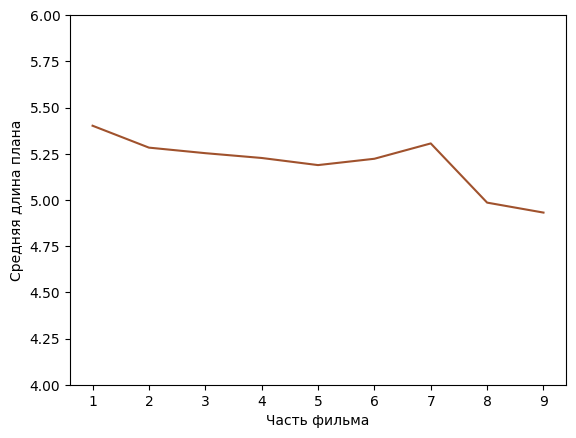

In [ ]:
shot_df.groupby('part_of_9')['time_length'].mean().plot(kind='line', ylim=(4, 6), color='sienna') # если шкалу от нуля, то не видно...
plt.xlabel('Часть фильма')
plt.ylabel('Средняя длина плана')

In [ ]:
metadata_df[['title', 'mean_scene']].sort_values('mean_scene').head(15)

,title,mean_scene
index,,
210,Con_Air,2.47
262,Enemy_of_the_State,2.50
31,Showdown_in_Little_Tokyo,2.74
208,FaceOff,2.78
259,Armageddon,2.80
149,Desperado,2.81
178,The_Rock,3.03
139,Stargate,3.05
255,Bride_of_Chucky,3.11


In [ ]:
metadata_df[['title', 'median_scene']].sort_values('median_scene').head(15)

,title,median_scene
index,,
31,Showdown_in_Little_Tokyo,1.88
210,Con_Air,1.92
149,Desperado,1.96
141,Timecop,2.00
262,Enemy_of_the_State,2.00
208,FaceOff,2.04
259,Armageddon,2.08
109,Demolition_Man,2.12
255,Bride_of_Chucky,2.12


In [ ]:
metadata_df[['title', 'mean_scene']].sort_values('mean_scene').tail(15)

,title,mean_scene
index,,
172,Murder_in_the_First,10.05
198,The_Whole_Wide_World,10.71
157,Before_Sunrise,10.80
83,Bitter_Moon,10.87
217,Boogie_Nights,11.34
106,Xi_yan,11.46
38,Night_on_Earth,11.57
122,Clerks,13.52
294,Eyes_Wide_Shut,15.94


In [ ]:
metadata_df[['title', 'median_scene']].sort_values('median_scene').tail(15)

,title,median_scene
index,,
172,Murder_in_the_First,6.04
98,Schindler's_List,6.12
266,The_Thin_Red_Line,6.17
42,Daughters_of_the_Dust,6.25
107,The_Remains_of_the_Day,6.31
83,Bitter_Moon,6.73
227,Firelight,6.79
38,Night_on_Earth,6.83
84,Bad_Lieutenant,8.25


In [ ]:
shot_df.groupby(['title'])['time_length'].max().sort_values()

,time_length
title,
Enemy_of_the_State,24.08
The_Long_Kiss_Goodnight,28.75
Speed,28.96
The_Negotiator,29.00
Con_Air,31.75
...,...
Sling_Blade,322.96
Clerks,325.62
The_Bridges_of_Madison_County,332.29


### Покадровые

#### Наличие лица в кадре

Text(0, 0.5, 'доля кадров')

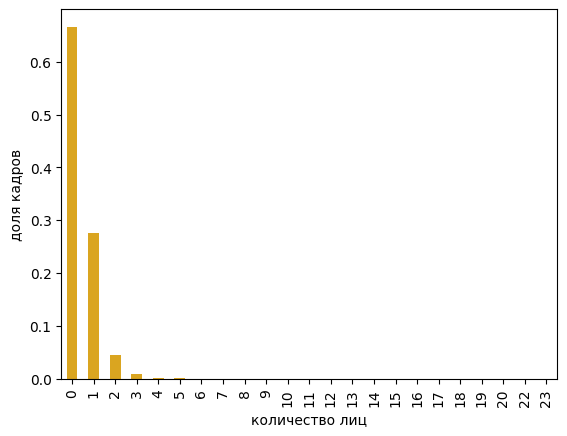

In [ ]:
frames_df['faces'].value_counts(normalize=True).sort_index().plot(kind='bar', color='goldenrod')
plt.xlabel('количество лиц')
plt.ylabel('доля кадров')

In [ ]:
frames_df.sort_values('faces', ascending=False).head(7)

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,length,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time
481276,212040,23,NaN,0,651,42.97,1565,Scent_of_a_Woman,212022.00,212080.00,58.00,2.42,02:27:14,3.00,6.00,9.00,1,human,02:27:15
1154061,237408,23,NaN,0,424,43.82,2773,Braveheart,237300.00,237411.00,111.00,4.62,02:44:47,3.00,6.00,9.00,1,human,02:44:52
480362,190104,22,NaN,0,433,36.41,1406,Scent_of_a_Woman,189953.00,190202.00,249.00,10.38,02:11:54,3.00,6.00,8.00,1,human,02:12:01
327689,125352,22,NaN,0,338,23.73,1012,The_People_Under_the_Stairs,125325.00,125377.00,52.00,2.17,01:27:01,3.00,6.00,8.00,1,human,01:27:03
2017412,226920,22,NaN,0,837,89.43,1507,Sunshine,226898.00,226994.00,96.00,4.00,02:37:34,3.00,6.00,9.00,1,human,02:37:35
1154060,237384,22,NaN,0,393,44.13,2773,Braveheart,237300.00,237411.00,111.00,4.62,02:44:47,3.00,6.00,9.00,1,human,02:44:51
1995394,140472,20,NaN,0,236,30.68,1383,Man_on_the_Moon,140432.00,140506.00,74.00,3.08,01:37:31,3.00,6.00,8.00,1,human,01:37:33


In [ ]:
frames_df['faces_bool'].mean()

np.float64(0.33431296974368857)

In [ ]:
frames_df.groupby('part_of_9')['faces_bool'].mean()

part_of_9
1.00   0.29
2.00   0.35
3.00   0.35
4.00   0.35
5.00   0.35
6.00   0.34
7.00   0.34
8.00   0.32
9.00   0.31
Name: faces_bool, dtype: float64

<Axes: xlabel='part_of_9'>

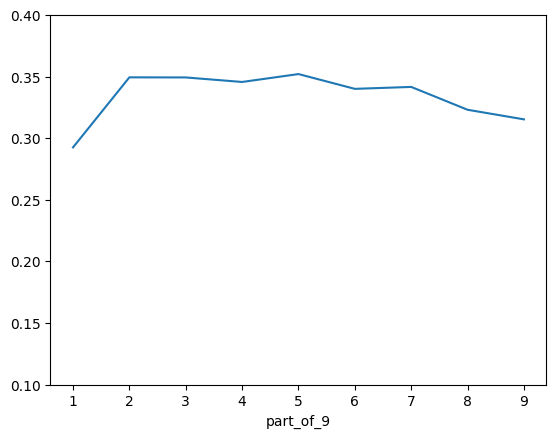

In [ ]:
frames_df.groupby('part_of_9')['faces_bool'].mean().plot(kind='line', ylim=(0.1, 0.4))

In [ ]:
metadata_df[['title', 'faces_bool']].sort_values('faces_bool')

,title,faces_bool
index,,
243,Fear_and_Loathing_in_Las_Vegas,0.13
80,Alien³,0.14
282,Wisconsin_Death_Trip,0.15
259,Armageddon,0.15
237,G.I._Jane,0.15
...,...,...
271,Office_Space,0.58
63,My_Cousin_Vinny,0.59
82,A_Few_Good_Men,0.59


#### Площадь лица

<Axes: >

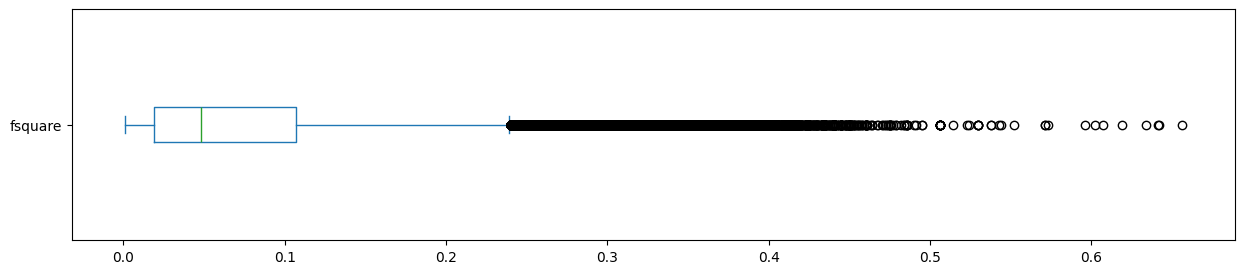

In [ ]:
frames_df[frames_df['fsquare'] != 0]['fsquare'].plot(kind='box', vert=False, figsize=(15, 3))

Text(0, 0.5, 'частота')

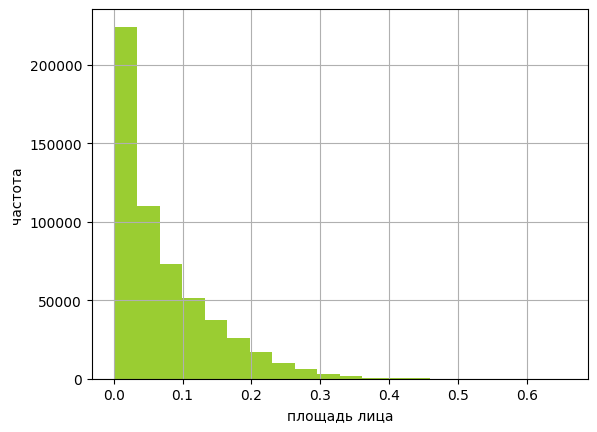

In [ ]:
frames_df[frames_df['fsquare'] > 0]['fsquare'].hist(bins=20, color='yellowgreen')
plt.xlabel('площадь лица')
plt.ylabel('частота')

In [ ]:
frames_df[frames_df['fsquare'] != 0]['fsquare'].describe()

,fsquare
count,560495.00
mean,0.07
std,0.07
min,0.00
25%,0.02
50%,0.05
75%,0.11
max,0.66


In [ ]:
frames_df[frames_df['fsquare'] != 0]['fsquare'].quantile(0.95)

np.float64(0.216)

In [ ]:
frames_df.groupby('title')['fsquare'].max().sort_values().tail(10)

In [ ]:
frames_df.groupby('part_of_9')['fsquare'].mean()

,fsquare
part_of_9,
1.00,0.02
2.00,0.02
3.00,0.02
4.00,0.02
5.00,0.02
6.00,0.02
7.00,0.02
8.00,0.02
9.00,0.02


In [ ]:
frames_df[frames_df['fsquare'] != 0].groupby('part_of_9')['fsquare'].mean()

,fsquare
part_of_9,
1.00,0.07
2.00,0.07
3.00,0.07
4.00,0.07
5.00,0.07
6.00,0.08
7.00,0.08
8.00,0.07
9.00,0.08


In [ ]:
frames_df.groupby('title')['fsquare'].max().sort_values().tail(10)

,fsquare
title,
Misery,0.49
The_Silence_of_the_Lambs,0.51
Thursday,0.51
Teenage_Mutant_Ninja_Turtles,0.52
Men_in_Black,0.53
Twin_Peaks_Fire_Walk_with_Me,0.54
Soldier_Boyz,0.60
Brainscan,0.64
Above_Suspicion,0.64


In [ ]:
frames_df[(frames_df['title'] == 'The_Silence_of_the_Lambs') & (frames_df['fsquare'] > 0)].sort_values('fsquare').tail(5)

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,length,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time
263561,21648,1,0.51,0,10,49.95,116,The_Silence_of_the_Lambs,21626.00,21890.00,264.00,11.00,00:15:01,1.00,1.00,2.00,1,closeup,00:15:02
263523,20736,1,0.51,2,13,42.98,107,The_Silence_of_the_Lambs,20353.00,20803.00,450.00,18.75,00:14:08,1.00,1.00,2.00,1,closeup,00:14:24
264811,51648,1,0.51,3,23,50.67,298,The_Silence_of_the_Lambs,51573.00,51661.00,88.00,3.67,00:35:48,1.00,2.00,3.00,1,closeup,00:35:52
267014,104520,1,0.51,3,4,29.80,638,The_Silence_of_the_Lambs,104436.00,104558.00,122.00,5.08,01:12:31,2.00,4.00,6.00,1,closeup,01:12:35
266926,102408,1,0.51,3,6,26.00,632,The_Silence_of_the_Lambs,102170.00,103698.00,1528.00,63.67,01:10:57,2.00,4.00,6.00,1,closeup,01:11:07


In [ ]:
metadata_df[['title', 'fsquare']].sort_values('fsquare')

,title,fsquare
index,,
125,Bullets_Over_Broadway,0.01
243,Fear_and_Loathing_in_Las_Vegas,0.01
20,Back_to_the_Future_Part_III,0.01
114,Menace_II_Society,0.01
67,Unforgiven,0.01
...,...,...
9,Misery,0.04
159,Dead_Man_Walking,0.05
36,The_Silence_of_the_Lambs,0.05


In [ ]:
frames_df['closeup'].value_counts(normalize=True)

,proportion
closeup,
none,0.67
human,0.26
medium closeup,0.07
closeup,0.01


<Axes: xlabel='closeup'>

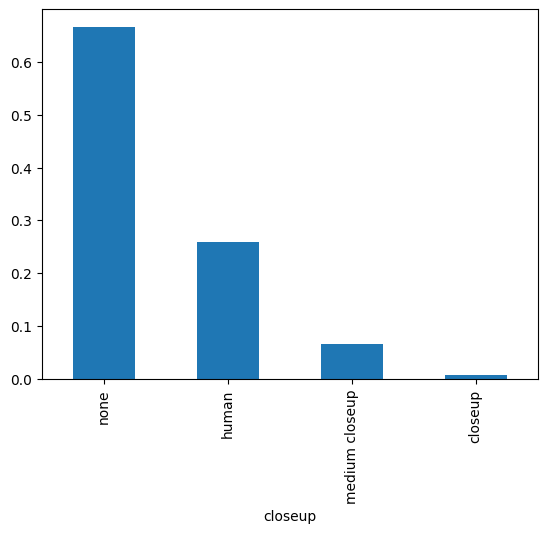

In [ ]:
frames_df['closeup'].value_counts(normalize=True).plot(kind='bar')

In [ ]:
frames_df.groupby('part_of_9')['closeup'].value_counts(normalize=True).unstack()

closeup,closeup,human,medium closeup,none
part_of_9,,,,
1.00,0.01,0.24,0.05,0.71
2.00,0.01,0.28,0.07,0.65
3.00,0.01,0.28,0.07,0.65
4.00,0.01,0.27,0.07,0.65
5.00,0.01,0.27,0.07,0.65
6.00,0.01,0.26,0.07,0.66
7.00,0.01,0.26,0.07,0.66
8.00,0.01,0.25,0.07,0.68
9.00,0.01,0.23,0.07,0.68


In [ ]:
metadata_df[['title', 'year', 'cu_close', 'fsquare']].sort_values('cu_close')

,title,year,cu_close,fsquare
index,,,,
77,Howards_End,1992,0.00,0.01
67,Unforgiven,1992,0.00,0.01
278,Man_on_the_Moon,1999,0.00,0.03
122,Clerks,1994,0.00,0.01
125,Bullets_Over_Broadway,1994,0.00,0.01
...,...,...,...,...
72,Wuthering_Heights,1992,0.04,0.05
211,As_Good_as_It_Gets,1997,0.04,0.05
249,American_History_X,1998,0.04,0.03


#### Количество глаз

In [ ]:
frames_df['neyes'].value_counts(normalize=True).head(5)

,proportion
neyes,
0,0.77
1,0.13
2,0.08
3,0.02
4,0.00


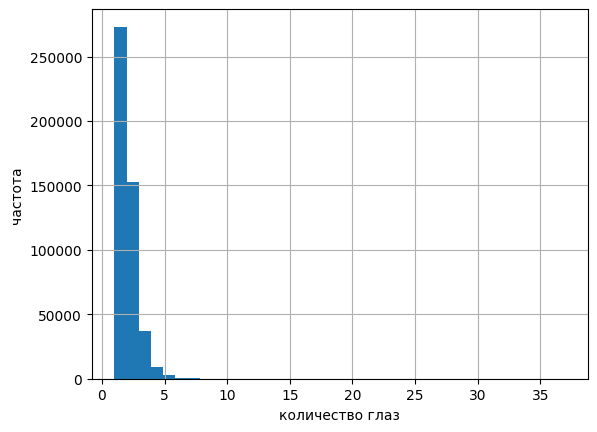

In [ ]:
frames_df[frames_df['neyes'] != 0]['neyes'].hist(bins=37)
plt.xlabel('количество глаз')
plt.ylabel('частота')
plt.show()

#### Количество контуров

<Axes: >

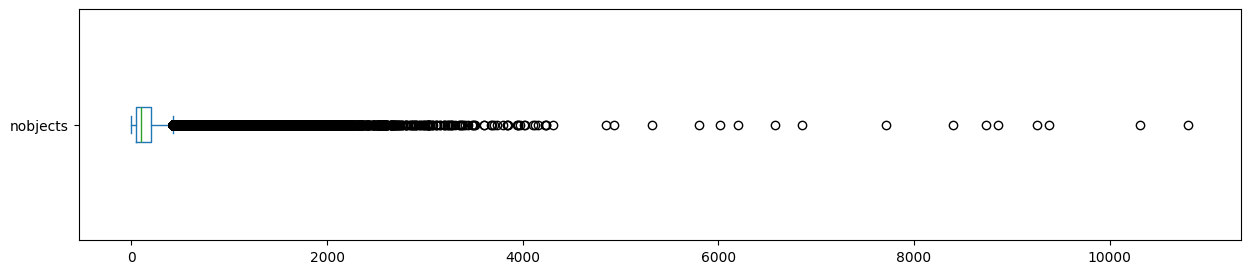

In [ ]:
frames_df['nobjects'].plot(kind='box', vert=False, figsize=(15, 3))

In [ ]:
frames_df['nobjects'].describe()

,nobjects
count,2034088.00
mean,153.25
std,174.31
min,0.00
25%,46.00
50%,100.00
75%,198.00
max,10804.00


In [ ]:
frames_df['nobjects'].quantile(0.99)

np.float64(835.0)

In [ ]:
frames_df[frames_df['nobjects'] > 8000]

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,length,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time
1129376,22560,0,0.00,0,8863,68.96,155,Dead_Man_Walking,22557.00,22706.00,149.00,6.21,00:15:39,1.00,1.00,2.00,0,none,00:15:40
1129377,22584,0,0.00,0,8738,69.25,155,Dead_Man_Walking,22557.00,22706.00,149.00,6.21,00:15:39,1.00,1.00,2.00,0,none,00:15:41
1129378,22608,0,0.00,0,8402,70.01,155,Dead_Man_Walking,22557.00,22706.00,149.00,6.21,00:15:39,1.00,1.00,2.00,0,none,00:15:42
1762498,48672,0,0.00,0,10310,80.81,550,American_History_X,48672.00,48771.00,99.00,4.12,00:33:48,1.00,2.00,3.00,0,none,00:33:48
1762499,48696,0,0.00,0,9379,75.95,550,American_History_X,48672.00,48771.00,99.00,4.12,00:33:48,1.00,2.00,3.00,0,none,00:33:49
1762500,48720,0,0.00,0,9254,75.41,550,American_History_X,48672.00,48771.00,99.00,4.12,00:33:48,1.00,2.00,3.00,0,none,00:33:50
1762502,48768,0,0.00,0,10804,85.45,550,American_History_X,48672.00,48771.00,99.00,4.12,00:33:48,1.00,2.00,3.00,0,none,00:33:52


In [ ]:
frames_df[frames_df['nobjects'] > 3000].sample(10)

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,length,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time
349961,84024,0,0.00,0,3383,63.88,678,Wild_Hearts_Can't_Be_Broken,83956.00,84243.00,287.00,11.96,00:58:18,3.00,5.00,7.00,0,none,00:58:21
1762500,48720,0,0.00,0,9254,75.41,550,American_History_X,48672.00,48771.00,99.00,4.12,00:33:48,1.00,2.00,3.00,0,none,00:33:50
788573,2928,0,0.00,0,3115,64.11,12,Freaked,2859.00,3063.00,204.00,8.50,00:01:59,1.00,1.00,1.00,0,none,00:02:02
1750257,19512,0,0.00,2,3248,62.74,160,The_Replacement_Killers,19373.00,19579.00,206.00,8.58,00:13:27,1.00,1.00,2.00,0,none,00:13:33
1750259,19560,0,0.00,0,3306,57.82,160,The_Replacement_Killers,19373.00,19579.00,206.00,8.58,00:13:27,1.00,1.00,2.00,0,none,00:13:35
1426927,94776,0,0.00,0,3004,71.89,729,Star_Trek_First_Contact,94743.00,94874.00,131.00,5.46,01:05:47,2.00,4.00,6.00,0,none,01:05:49
1602617,64104,0,0.00,0,3025,76.57,466,Scream_2,63973.00,64184.00,211.00,8.79,00:44:25,2.00,3.00,4.00,0,none,00:44:31
349970,84240,0,0.00,0,3513,60.96,678,Wild_Hearts_Can't_Be_Broken,83956.00,84243.00,287.00,11.96,00:58:18,3.00,5.00,7.00,0,none,00:58:30
1059749,13824,1,0.02,0,3031,42.03,202,Desperado,13790.00,13875.00,85.00,3.54,00:09:34,1.00,1.00,1.00,1,human,00:09:36
349959,83976,0,0.00,0,3972,90.31,678,Wild_Hearts_Can't_Be_Broken,83956.00,84243.00,287.00,11.96,00:58:18,3.00,5.00,7.00,0,none,00:58:19


In [ ]:
frames_df[frames_df['nobjects'] < 5].sample(10)

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,length,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time
669298,206472,0,0.00,0,1,26.06,2054,Bound_by_Honor,206468.00,206525.00,57.00,2.38,02:23:22,3.00,5.00,7.00,0,none,02:23:23
547169,3792,0,0.00,0,0,41.18,1,Husbands_and_Wives,3287.00,3850.00,563.00,23.46,00:02:16,1.00,1.00,1.00,0,none,00:02:38
614764,7968,0,0.00,0,1,4.45,19,The_Last_of_the_Mohicans,6557.00,7989.00,1432.00,59.67,00:04:33,1.00,1.00,1.00,0,none,00:05:32
2091933,106944,0,0.00,1,4,21.55,977,The_Thirteenth_Floor,106913.00,107191.00,278.00,11.58,01:14:14,3.00,5.00,7.00,0,none,01:14:16
1460748,21216,0,0.00,0,1,8.79,107,In_Love_and_War,21214.00,21253.00,39.00,1.62,00:14:43,1.00,1.00,2.00,0,none,00:14:44
600627,14736,1,0.17,1,3,8.49,74,A_Midnight_Clear,14141.00,14765.00,624.00,26.00,00:09:49,1.00,1.00,1.00,1,medium closeup,00:10:14
856913,124248,0,0.00,0,1,19.36,1244,The_Crow,124234.00,124305.00,71.00,2.96,01:26:16,3.00,6.00,9.00,0,none,01:26:17
302098,91800,0,0.00,0,0,176.34,443,Daughters_of_the_Dust,91725.00,92038.00,313.00,13.04,01:03:41,2.00,4.00,6.00,0,none,01:03:45
605172,123816,2,NaN,0,3,17.07,599,A_Midnight_Clear,122835.00,124377.00,1542.00,64.25,01:25:18,3.00,5.00,8.00,1,human,01:25:59
1059206,792,0,0.00,0,1,25.97,0,Desperado,757.00,836.00,79.00,3.29,00:00:31,1.00,1.00,1.00,0,none,00:00:33


In [ ]:
frames_df['nobjects'].quantile(0.03)

np.float64(5.0)

In [ ]:
frames_df.loc[frames_df['nobjects'] > 4200, 'nobjects'] = np.nan

In [ ]:
frames_df['nobjects'].describe()

,nobjects
count,2034068.00
mean,153.19
std,172.91
min,0.00
25%,46.00
50%,100.00
75%,198.00
max,4158.00


<Axes: >

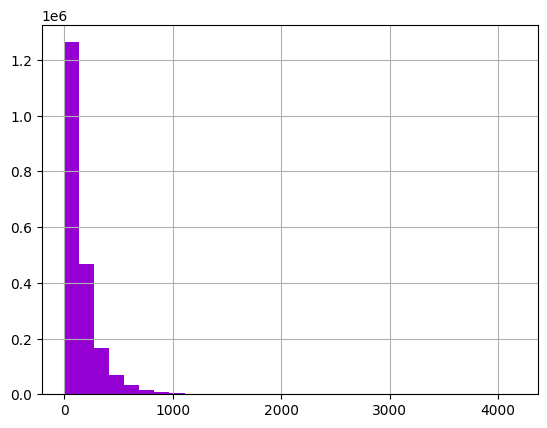

In [ ]:
frames_df['nobjects'].hist(bins=30, color='darkviolet')

In [ ]:
frames_df.groupby('part_of_9')['nobjects'].mean() # в последнюю часть теоретически могли затесаться титры?

,nobjects
part_of_9,
1.00,166.23
2.00,161.19
3.00,154.09
4.00,156.51
5.00,150.03
6.00,148.33
7.00,144.41
8.00,143.62
9.00,154.13


Text(0, 0.5, 'Среднее количество объектов')

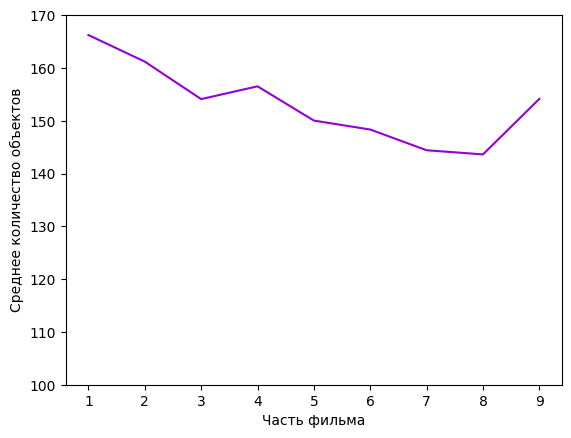

In [ ]:
frames_df.groupby('part_of_9')['nobjects'].mean().plot(kind='line', ylim=(100, 170), color='darkviolet')
plt.xlabel('Часть фильма')
plt.ylabel('Среднее количество объектов')

In [ ]:
frames_df[frames_df['nobjects'] == 0] # 1 процент

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,length,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time
158,3792,0,0.00,0,0.00,71.32,32,Die_Hard_2,3708.00,3932.00,224.00,9.33,00:02:34,1.00,1.00,1.00,0,none,00:02:38
173,4152,0,0.00,0,0.00,30.53,34,Die_Hard_2,4037.00,4203.00,166.00,6.92,00:02:48,1.00,1.00,1.00,0,none,00:02:53
189,4536,0,0.00,0,0.00,31.36,37,Die_Hard_2,4403.00,4573.00,170.00,7.08,00:03:03,1.00,1.00,1.00,0,none,00:03:09
223,5352,0,0.00,0,0.00,26.44,48,Die_Hard_2,5332.00,5457.00,125.00,5.21,00:03:42,1.00,1.00,1.00,0,none,00:03:43
224,5376,0,0.00,0,0.00,16.61,48,Die_Hard_2,5332.00,5457.00,125.00,5.21,00:03:42,1.00,1.00,1.00,0,none,00:03:44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2133450,71616,0,0.00,0,0.00,170.06,814,Three_Kings,71433.00,71690.00,257.00,10.71,00:49:36,2.00,3.00,5.00,0,none,00:49:44
2135899,130392,0,0.00,0,0.00,237.68,1319,Three_Kings,130336.00,130498.00,162.00,6.75,01:30:30,3.00,5.00,8.00,0,none,01:30:33
2136135,136056,0,0.00,0,0.00,0.92,1358,Three_Kings,136026.00,136065.00,39.00,1.62,01:34:27,3.00,6.00,8.00,0,none,01:34:29
2136436,143280,0,0.00,0,0.00,110.84,1421,Three_Kings,143155.00,143280.00,125.00,5.21,01:39:24,3.00,6.00,9.00,0,none,01:39:30


In [ ]:
metadata_df[['title', 'nobjects']].sort_values('nobjects')

,title,nobjects
index,,
288,The_End_of_the_Affair,47.85
203,Bound,54.06
227,Firelight,55.97
277,Being_John_Malkovich,57.82
16,Flatliners,58.56
...,...,...
125,Bullets_Over_Broadway,356.24
57,McBain,393.79
265,Saving_Private_Ryan,395.17


#### Яркость

<Axes: >

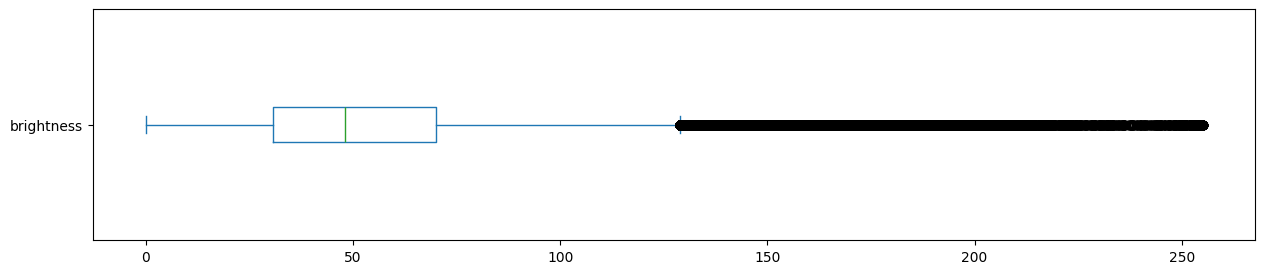

In [ ]:
frames_df['brightness'].plot(kind='box', vert=False, figsize=(15, 3))

Text(0, 0.5, 'Частота')

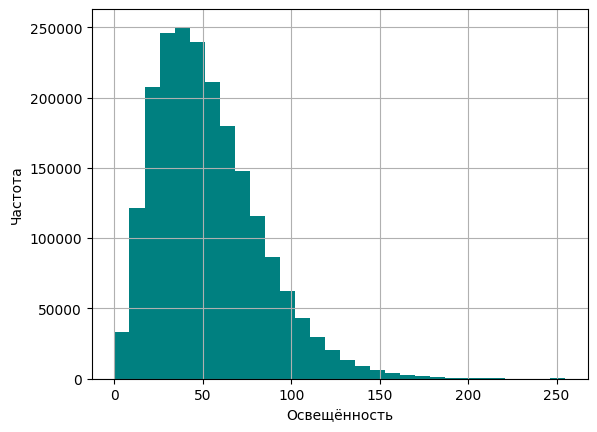

In [ ]:
frames_df['brightness'].hist(bins=30, color='teal')
plt.xlabel('Освещённость')
plt.ylabel('Частота')

In [ ]:
frames_df['brightness'].describe()

,brightness
count,2034088.00
mean,52.89
std,29.70
min,0.00
25%,30.61
50%,48.04
75%,69.95
max,255.00


In [ ]:
frames_df.groupby('part_of_9')['brightness'].mean()

,brightness
part_of_9,
1.00,53.38
2.00,54.78
3.00,52.86
4.00,54.28
5.00,52.47
6.00,52.40
7.00,50.44
8.00,51.29
9.00,54.07


In [ ]:
frames_df[frames_df['brightness'] < 30].sample(5)

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,length,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time
2050680,121944,2,NaN,1,50,20.61,846,Stir_of_Echoes,121829.00,121975.00,146.00,6.08,01:24:36,3.00,5.00,8.00,1,human,01:24:41
1584059,156432,0,0.00,0,19,12.42,1008,Rosewood,156380.00,156434.00,54.00,2.25,01:48:35,3.00,5.00,8.00,0,none,01:48:38
1991958,58008,1,0.01,0,56,14.92,548,Man_on_the_Moon,57957.00,58183.00,226.00,9.42,00:40:14,2.00,3.00,4.00,1,human,00:40:17
537517,219744,0,0.00,0,9,5.77,1253,Twin_Peaks_Fire_Walk_with_Me,219075.00,219754.00,679.00,28.29,02:32:08,3.00,6.00,9.00,0,none,02:32:36
1557854,143808,3,NaN,0,127,26.70,991,Donnie_Brasco,143671.00,143820.00,149.00,6.21,01:39:46,3.00,5.00,7.00,1,human,01:39:52


In [ ]:
frames_df[frames_df['brightness'] > 80].sample(5)

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,length,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time
867980,40896,1,0.01,0,744,86.75,141,Clerks,40614.00,41827.00,1213.00,50.54,00:28:12,1.00,2.00,3.00,1,human,00:28:24
1197579,176136,0,0.00,0,180,86.84,1096,Sense_and_Sensibility,175234.00,176317.00,1083.00,45.12,02:01:41,3.00,6.00,9.00,0,none,02:02:19
1515280,61872,1,0.18,0,41,83.86,483,Roseanna's_Grave,61811.00,62013.00,202.00,8.42,00:42:55,2.00,3.00,5.00,1,medium closeup,00:42:58
723493,58800,0,0.00,0,173,80.99,286,Geronimo_An_American_Legend,58064.00,58821.00,757.00,31.54,00:40:19,2.00,3.00,4.00,0,none,00:40:50
307411,57816,0,0.00,0,105,87.70,502,JFK,57726.00,57849.00,123.00,5.12,00:40:05,1.00,2.00,2.00,0,none,00:40:09


In [ ]:
frames_df[frames_df['brightness'] > 150].sample(5)

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,length,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time
353978,52224,0,0.00,1,288,157.36,501,Final_Approach,52199.00,52232.00,33.00,1.38,00:36:14,2.00,3.00,4.00,0,none,00:36:16
635572,2712,0,0.00,0,3,196.17,10,The_Fugitive,2678.00,2767.00,89.00,3.71,00:01:51,1.00,1.00,1.00,0,none,00:01:53
639260,91224,0,0.00,0,0,248.45,841,The_Fugitive,91129.00,91478.00,349.00,14.54,01:03:17,2.00,4.00,5.00,0,none,01:03:21
392858,157968,1,0.04,1,201,152.42,1350,Flight_of_the_Intruder,157945.00,158269.00,324.00,13.50,01:49:41,3.00,6.00,9.00,1,human,01:49:42
1901686,150840,0,0.00,0,228,158.63,715,Saving_Private_Ryan,150390.00,152309.00,1919.00,79.96,01:44:26,2.00,4.00,6.00,0,none,01:44:45


In [ ]:
frames_df[round(frames_df['brightness']) == 50].sample(3)

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,length,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time
1572926,111816,0,0.00,0,79,50.36,558,Amistad,111802.00,111898.00,96.00,4.00,01:17:38,2.00,4.00,5.00,0,none,01:17:39
1535136,20784,3,NaN,1,174,50.49,195,L.A._Confidential,20763.00,20884.00,121.00,5.04,00:14:25,1.00,1.00,1.00,1,human,00:14:26
558185,34080,0,0.00,1,44,50.24,326,Alien³,33812.00,34145.00,333.00,13.88,00:23:28,1.00,1.00,2.00,0,none,00:23:40


In [ ]:
metadata_df[['title', 'brightness']].sort_values('brightness')

,title,brightness
index,,
74,Dracula,21.51
128,Interview_with_the_Vampire_The_Vampire_Chronicles,22.23
90,Judgment_Night,23.14
119,The_Crow,23.65
45,The_People_Under_the_Stairs,26.29
...,...,...
42,Daughters_of_the_Dust,89.74
122,Clerks,95.82
296,Three_Kings,96.07


In [7]:
frames_df[(frames_df['nframe'] == 58008)&(frames_df['title'] == 'Man_on_the_Moon')]

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title
1991958,58008,1,0.01,0,56,14.92,548,Man_on_the_Moon
